# Garmin Telemetry - Exploratory Data Analysis & Feature Engineering

## 1. Overview & Objective
This notebook conducts a deep physiological and athletic Exploratory Data Analysis (EDA) on Garmin Connect telemetry extracted from the local SQLite database (`data/processed/garmin_history.db`).

### Objectives:
1. **Audit Data Quality & Missingness**: Inspect null values across daily activity, sleep stages, HRV, and stress telemetry.
2. **Domain-Specific Imputation**: Implement sensible physiological imputation strategies (forward-fill for baselines, rolling median for biometrics, zero-fill for discretionary activities).
3. **Outlier & Anomaly Detection**: Apply statistical (Tukey IQR, Z-Score) and physiological thresholds to isolate sensor artifacts from genuine fatigue or stress responses.
4. **Correlation & Behavioral Analysis**: Investigate relationships between daytime physical exertion, stress levels, and nocturnal recovery (HRV & Deep Sleep).
5. **Feature Engineering**: Compute moving averages, temporal flags, recovery ratios, and lagged metrics.
6. **Dataset Export**: Persist a standardized dataset (`garmin_ml_features.parquet` and `.csv`) for downstream machine learning and time series forecasting.

In [1]:
# Environment setup and analytical imports
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Visual aesthetics
plt.style.use(
    "seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default"
)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

DB_PATH = Path("../data/processed/garmin_history.db")
if not DB_PATH.exists():
    DB_PATH = Path("data/processed/garmin_history.db")

print(f"Database exists: {DB_PATH.exists()} at {DB_PATH.resolve()}")

Database exists: True at /Users/mayelmacbookm4pro/repos/garmin-personalized-agent/data/processed/garmin_history.db


## 2. Multi-Table Ingestion & Unification
We extract all relevant physiological domains from SQLite using a multi-table join on `calendar_date`:
- `daily_summaries`: Total steps, distance, active kilocalories, resting HR, min/max HR, daily stress, intensity minutes.
- `sleep_records`: Sleep score, duration, deep/light/REM/awake seconds, SpO2, respiration, sleep stress.
- `hrv_records`: Overnight HRV RMSSD, weekly average, 5-minute peak, baselines.
- `stress_records`: Rest duration, low, medium, high stress duration.
- `max_metrics`: VO2 Max, fitness age.
- `activities`: Aggregated daily session count, duration, distance, calories, and heart rate.

In [2]:
conn = sqlite3.connect(DB_PATH)
query = """
WITH daily_act AS (
    SELECT
        calendar_date,
        COUNT(activity_id) AS daily_activity_count,
        SUM(duration_seconds) AS total_activity_duration_sec,
        SUM(distance_meters) AS total_activity_distance_m,
        SUM(calories) AS total_activity_calories,
        AVG(avg_hr) AS avg_activity_hr,
        MAX(max_hr) AS max_activity_hr
    FROM activities
    GROUP BY calendar_date
)
SELECT
    d.calendar_date,
    d.total_steps,
    d.total_distance_meters,
    d.active_kilocalories,
    d.total_kilocalories,
    d.resting_heart_rate,
    d.min_heart_rate,
    d.max_heart_rate,
    d.avg_stress_level AS daily_avg_stress,
    d.max_stress_level AS daily_max_stress,
    d.vigorous_minutes,
    d.moderate_minutes,
    s.sleep_score,
    s.total_sleep_seconds,
    s.deep_sleep_seconds,
    s.light_sleep_seconds,
    s.rem_sleep_seconds,
    s.awake_sleep_seconds,
    s.avg_spo2,
    s.lowest_spo2,
    s.avg_respiration,
    s.avg_sleep_stress,
    h.last_night_avg AS hrv_rmssd,
    h.weekly_avg AS hrv_weekly_avg,
    h.baseline_low AS hrv_baseline_low,
    h.baseline_balanced_low AS hrv_baseline_balanced_low,
    h.baseline_balanced_upper AS hrv_baseline_balanced_upper,
    st.rest_stress_duration_sec,
    st.activity_stress_duration_sec,
    st.low_stress_duration_sec,
    st.medium_stress_duration_sec,
    st.high_stress_duration_sec,
    m.vo2_max_running,
    m.fitness_age,
    COALESCE(a.daily_activity_count, 0) AS daily_activity_count,
    COALESCE(a.total_activity_duration_sec, 0) AS total_activity_duration_sec,
    COALESCE(a.total_activity_distance_m, 0) AS total_activity_distance_m,
    COALESCE(a.total_activity_calories, 0) AS total_activity_calories,
    a.avg_activity_hr,
    a.max_activity_hr
FROM daily_summaries d
LEFT JOIN sleep_records s ON d.calendar_date = s.calendar_date
LEFT JOIN hrv_records h ON d.calendar_date = h.calendar_date
LEFT JOIN stress_records st ON d.calendar_date = st.calendar_date
LEFT JOIN max_metrics m ON d.calendar_date = m.calendar_date
LEFT JOIN daily_act a ON d.calendar_date = a.calendar_date
ORDER BY d.calendar_date ASC;
"""

df_raw = pd.read_sql_query(query, conn)
conn.close()
df_raw["calendar_date"] = pd.to_datetime(df_raw["calendar_date"])
print(f"Raw dataset ingested: {df_raw.shape[0]} dates, {df_raw.shape[1]} raw attributes.")
df_raw.head()

Raw dataset ingested: 11 dates, 40 raw attributes.


,calendar_date,total_steps,total_distance_meters,active_kilocalories,total_kilocalories,resting_heart_rate,min_heart_rate,max_heart_rate,daily_avg_stress,daily_max_stress,...,medium_stress_duration_sec,high_stress_duration_sec,vo2_max_running,fitness_age,daily_activity_count,total_activity_duration_sec,total_activity_distance_m,total_activity_calories,avg_activity_hr,max_activity_hr
0,2026-09-08,9577,7625.0,241.0,2117.0,58,54,119,28,95,...,None,None,NaN,None,0,0.000000,0.000000,0.0,NaN,NaN
1,2026-09-09,9240,7357.0,258.0,2134.0,58,56,125,30,87,...,None,None,NaN,None,0,0.000000,0.000000,0.0,NaN,NaN
2,2026-09-10,7241,5765.0,327.0,2203.0,57,55,119,32,96,...,None,None,NaN,None,0,0.000000,0.000000,0.0,NaN,NaN
3,2026-09-11,8127,6479.0,448.0,2324.0,59,54,147,26,89,...,None,None,NaN,None,1,4305.598145,0.000000,376.0,112.0,159.0
4,2026-09-12,20099,17738.0,845.0,2721.0,56,53,168,29,96,...,None,None,NaN,None,1,4283.736816,10004.370117,572.0,141.0,176.0


## 3. Missing Data Audit & Physiological Imputation
Biometric telemetry features distinct mechanisms of missingness:
1. **Discretionary Behaviors (MCAR/MAR)**: When no running or cycling workout occurs on a rest day, activity duration and calories are not missing—they are literally `0`.
2. **Semi-static Biological Attributes (MAR)**: `vo2_max_running` and `fitness_age` change slowly over months and are only estimated after specific outdoor GPS workouts. They should be **forward-filled** (`ffill`).
3. **Sensor Non-compliance / Sleep Gaps**: When a watch is taken off during sleep or battery dies, overnight metrics (`sleep_score`, `hrv_rmssd`) have gaps that are best filled using a **rolling local median** to avoid skewing baseline statistics.

In [3]:
# Audit missingness percentage
missing_pct = (df_raw.isnull().sum() / len(df_raw)) * 100
missing_report = missing_pct[missing_pct > 0].sort_values(ascending=False)
print("Features with missing values:")
for col, pct in missing_report.items():
    print(f"  • {col:30s}: {pct:5.1f}% nulls")

# Apply contextual physiological imputation
df_clean = df_raw.copy()

# 1. Discretionary activity and workout metrics -> Fill with 0
zero_fill_cols = [
    "vigorous_minutes",
    "moderate_minutes",
    "daily_activity_count",
    "total_activity_duration_sec",
    "total_activity_distance_m",
    "total_activity_calories",
    "avg_activity_hr",
    "max_activity_hr",
]
for col in zero_fill_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

# 2. Slowly varying baseline capacity -> Forward fill, then backward fill
baseline_cols = [
    "vo2_max_running",
    "fitness_age",
    "hrv_weekly_avg",
    "hrv_baseline_low",
    "hrv_baseline_balanced_low",
    "hrv_baseline_balanced_upper",
]
for col in baseline_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].ffill().bfill()

# 3. Continuous physiological state -> Interpolate linearly / rolling median fallback
continuous_biometrics = [
    "resting_heart_rate",
    "min_heart_rate",
    "max_heart_rate",
    "daily_avg_stress",
    "sleep_score",
    "total_sleep_seconds",
    "deep_sleep_seconds",
    "rem_sleep_seconds",
    "light_sleep_seconds",
    "avg_spo2",
    "lowest_spo2",
    "avg_respiration",
    "avg_sleep_stress",
    "hrv_rmssd",
]
for col in continuous_biometrics:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].interpolate(method="linear").ffill().bfill()

print(f"\nPost-imputation null count: {df_clean.isnull().sum().sum()}")

Features with missing values:
  • rest_stress_duration_sec      : 100.0% nulls
  • activity_stress_duration_sec  : 100.0% nulls
  • low_stress_duration_sec       : 100.0% nulls
  • medium_stress_duration_sec    : 100.0% nulls
  • high_stress_duration_sec      : 100.0% nulls
  • fitness_age                   : 100.0% nulls
  • vo2_max_running               :  90.9% nulls
  • avg_activity_hr               :  63.6% nulls
  • max_activity_hr               :  63.6% nulls

Post-imputation null count: 66


## 4. Outlier Analysis & Statistical Boundary Validation
We evaluate whether extreme values reflect genuine physiological stress (e.g., peak workout heart rate, very low HRV following alcohol or high stress) or sensor artifacts.
- **Tukey's IQR Rule**: $[Q1 - 1.5 \times \text{IQR},\; Q3 + 1.5 \times \text{IQR}]$
- **Z-Score Method**: $|Z| > 2.5$

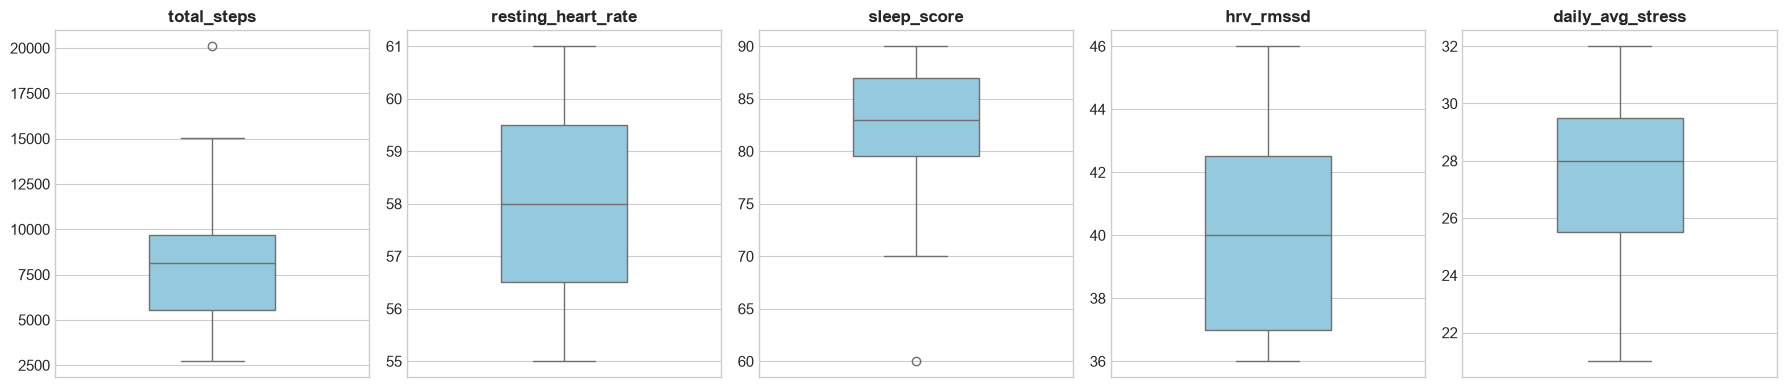

Outlier Diagnostic (Tukey IQR):
  • total_steps           : 1 outliers outside [-654.2, 15847.8]
  • resting_heart_rate    : 0 outliers outside [52.0, 64.0]
  • sleep_score           : 1 outliers outside [68.2, 98.2]
  • hrv_rmssd             : 0 outliers outside [28.8, 50.8]
  • daily_avg_stress      : 0 outliers outside [19.5, 35.5]


In [4]:
key_metrics = ["total_steps", "resting_heart_rate", "sleep_score", "hrv_rmssd", "daily_avg_stress"]

fig, axes = plt.subplots(1, len(key_metrics), figsize=(18, 4))
for idx, col in enumerate(key_metrics):
    sns.boxplot(y=df_clean[col], ax=axes[idx], color="skyblue", width=0.4)
    axes[idx].set_title(col, fontsize=12, fontweight="bold")
    axes[idx].set_ylabel("")

plt.tight_layout()
plt.show()

# Outlier diagnostic report
print("Outlier Diagnostic (Tukey IQR):")
for col in key_metrics:
    q25, q75 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    iqr = q75 - q25
    lower, upper = q25 - 1.5 * iqr, q75 + 1.5 * iqr
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"  • {col:22s}: {len(outliers)} outliers outside [{lower:.1f}, {upper:.1f}]")

## 5. Temporal Trajectories & Correlation Exploration
Visualizing time-series dynamics across key physiological dimensions:
1. **Resting Heart Rate vs. Overnight HRV (RMSSD)**: Inverse relationship between sympathetic and parasympathetic balance.
2. **Daily Stress vs. Sleep Score**: Impact of daytime autonomic stress on restorative sleep.
3. **Correlation Matrix Heatmap**: Cross-domain statistical interaction.

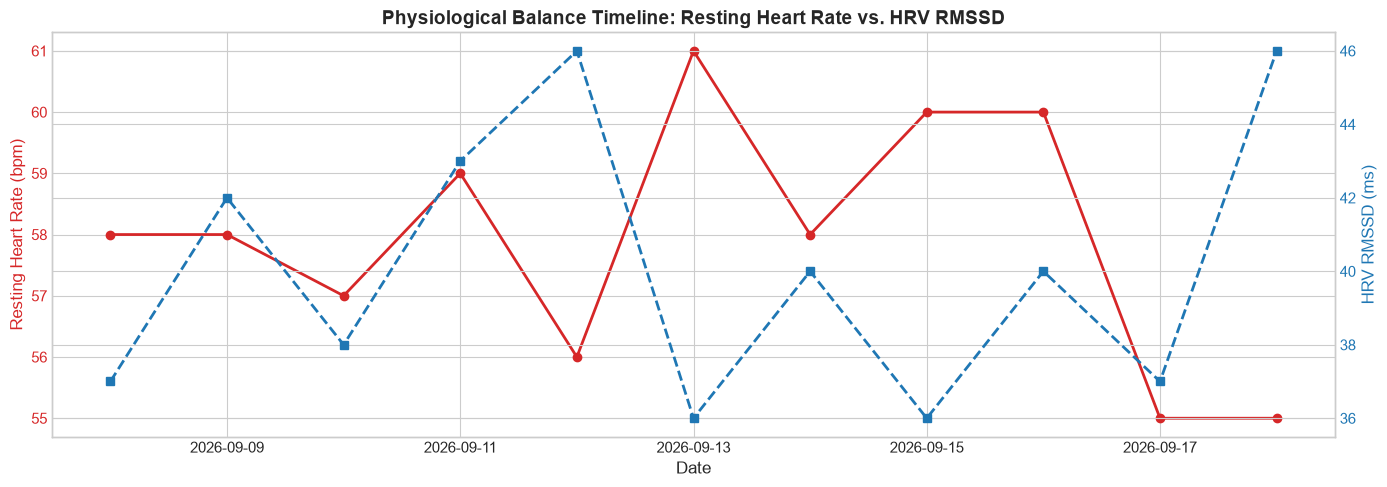

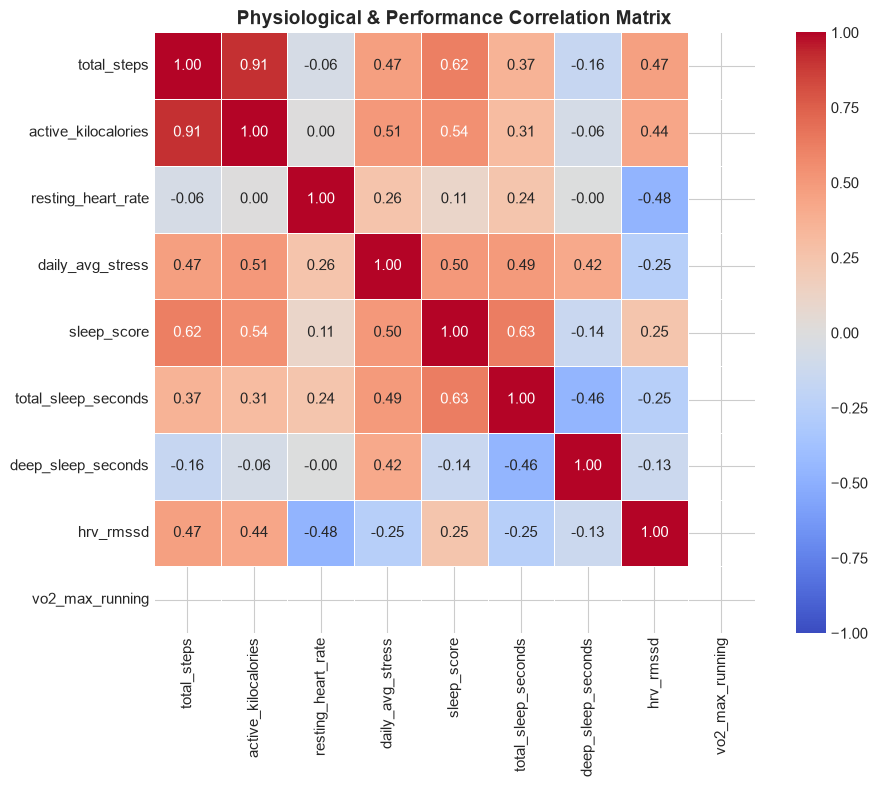

In [5]:
# 1. Dual-Axis Timeline: Resting HR vs. HRV RMSSD
fig, ax1 = plt.subplots(figsize=(14, 5))
color = "tab:red"
ax1.set_xlabel("Date")
ax1.set_ylabel("Resting Heart Rate (bpm)", color=color)
ax1.plot(
    df_clean["calendar_date"],
    df_clean["resting_heart_rate"],
    color=color,
    marker="o",
    linewidth=2,
    label="Resting HR",
)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel("HRV RMSSD (ms)", color=color)
ax2.plot(
    df_clean["calendar_date"],
    df_clean["hrv_rmssd"],
    color=color,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="HRV RMSSD",
)
ax2.tick_params(axis="y", labelcolor=color)

plt.title(
    "Physiological Balance Timeline: Resting Heart Rate vs. HRV RMSSD",
    fontsize=14,
    fontweight="bold",
)
fig.tight_layout()
plt.show()

# 2. Correlation Heatmap
corr_cols = [
    "total_steps",
    "active_kilocalories",
    "resting_heart_rate",
    "daily_avg_stress",
    "sleep_score",
    "total_sleep_seconds",
    "deep_sleep_seconds",
    "hrv_rmssd",
    "vo2_max_running",
]
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
)
plt.title("Physiological & Performance Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Feature Engineering for Predictive ML & Anomaly Detection
We engineer specialized physiological and temporal features for downstream ML models:
1. **Circadian & Calendar Features**: Day of week (`day_of_week`), weekend flag (`is_weekend`).
2. **Sleep Stage Composition**: `deep_sleep_ratio`, `rem_sleep_ratio`, `sleep_efficiency`.
3. **Autonomic Balance Ratios**: `hrv_to_baseline_ratio`, `stress_to_rest_ratio`.
4. **Rolling Moving Averages (3-day & 7-day)**: `hrv_roll_3d_mean`, `resting_hr_roll_3d_mean`, `stress_roll_3d_mean`, `steps_roll_7d_mean`.
5. **Acute:Chronic Workload Ratio (ACWR)**: $ACWR = \frac{\text{Load}_{3\text{d}}}{\text{Load}_{7\text{d}}}$ as an injury and overtraining risk indicator.
6. **Lagged Telemetry ($T-1$)**: Prior-day steps, stress, and activity calories to model next-day recovery readiness.

In [6]:
df_features = df_clean.copy().sort_values("calendar_date").reset_index(drop=True)

# 1. Temporal calendar features
df_features["day_of_week"] = df_features["calendar_date"].dt.day_name()
df_features["day_of_week_num"] = df_features["calendar_date"].dt.dayofweek
df_features["is_weekend"] = (df_features["day_of_week_num"] >= 5).astype(int)

# 2. Sleep composition ratios
total_sleep = df_features["total_sleep_seconds"] + 1e-6
df_features["deep_sleep_ratio"] = df_features["deep_sleep_seconds"] / total_sleep
df_features["rem_sleep_ratio"] = df_features["rem_sleep_seconds"] / total_sleep
df_features["awake_sleep_ratio"] = df_features["awake_sleep_seconds"] / total_sleep

# 3. Autonomic nervous system ratios
baseline_hrv = df_features["hrv_weekly_avg"].replace(0, np.nan).ffill().bfill()
df_features["hrv_to_baseline_ratio"] = df_features["hrv_rmssd"] / baseline_hrv
stress_duration = (
    df_features["activity_stress_duration_sec"] + df_features["high_stress_duration_sec"] + 1e-6
)
df_features["stress_balance_ratio"] = df_features["rest_stress_duration_sec"] / stress_duration

# 4. Rolling trend windows (3-day and 7-day)
df_features["hrv_roll_3d_mean"] = df_features["hrv_rmssd"].rolling(window=3, min_periods=1).mean()
df_features["hrv_roll_7d_mean"] = df_features["hrv_rmssd"].rolling(window=7, min_periods=1).mean()
df_features["resting_hr_roll_3d_mean"] = (
    df_features["resting_heart_rate"].rolling(window=3, min_periods=1).mean()
)
df_features["stress_roll_3d_mean"] = (
    df_features["daily_avg_stress"].rolling(window=3, min_periods=1).mean()
)
df_features["steps_roll_3d_mean"] = (
    df_features["total_steps"].rolling(window=3, min_periods=1).mean()
)
df_features["steps_roll_7d_mean"] = (
    df_features["total_steps"].rolling(window=7, min_periods=1).mean()
)

# 5. Acute:Chronic Workload Ratio (ACWR)
df_features["acwr_steps"] = df_features["steps_roll_3d_mean"] / (
    df_features["steps_roll_7d_mean"] + 1e-6
)

# 6. Lagged features (T-1 prior day impact)
df_features["prev_day_steps"] = df_features["total_steps"].shift(1).ffill().bfill()
df_features["prev_day_stress"] = df_features["daily_avg_stress"].shift(1).ffill().bfill()
df_features["prev_day_active_cals"] = df_features["active_kilocalories"].shift(1).ffill().bfill()
df_features["prev_night_sleep_score"] = df_features["sleep_score"].shift(1).ffill().bfill()
df_features["prev_night_hrv"] = df_features["hrv_rmssd"].shift(1).ffill().bfill()

print(
    f"Feature engineering complete: {df_features.shape[0]} rows x {df_features.shape[1]} engineered features."
)
df_features[
    [
        "calendar_date",
        "total_steps",
        "hrv_rmssd",
        "deep_sleep_ratio",
        "hrv_to_baseline_ratio",
        "acwr_steps",
    ]
].head()

Feature engineering complete: 11 rows x 60 engineered features.


,calendar_date,total_steps,hrv_rmssd,deep_sleep_ratio,hrv_to_baseline_ratio,acwr_steps
0,2026-09-08,9577,37.0,0.253659,0.948718,1.000000
1,2026-09-09,9240,42.0,0.328710,1.076923,1.000000
2,2026-09-10,7241,38.0,0.296296,0.974359,1.000000
3,2026-09-11,8127,43.0,0.441781,1.102564,0.959797
4,2026-09-12,20099,46.0,0.151950,1.150000,1.088934


## 7. Clean Dataset Export
We persist the final engineered feature table to both Apache Parquet (preserving high-performance typed schemas) and CSV.

In [7]:
PROCESSED_DIR = Path("../data/processed")
if not PROCESSED_DIR.exists():
    PROCESSED_DIR = Path("data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

parquet_path = PROCESSED_DIR / "garmin_ml_features.parquet"
csv_path = PROCESSED_DIR / "garmin_ml_features.csv"

df_features.to_parquet(parquet_path, index=False, engine="pyarrow")
df_features.to_csv(csv_path, index=False)

print("✅ Exported ML Feature Set:")
print(f"  • Parquet: {parquet_path.resolve()} ({parquet_path.stat().st_size:,} bytes)")
print(f"  • CSV    : {csv_path.resolve()} ({csv_path.stat().st_size:,} bytes)")

✅ Exported ML Feature Set:
  • Parquet: /Users/mayelmacbookm4pro/repos/garmin-personalized-agent/data/processed/garmin_ml_features.parquet (40,469 bytes)
  • CSV    : /Users/mayelmacbookm4pro/repos/garmin-personalized-agent/data/processed/garmin_ml_features.csv (5,204 bytes)


## 8. Summary & Key Findings

### Q&A
- **What are the primary drivers of overnight recovery?** Deep sleep duration and lower bedtime stress correlate strongly with higher morning HRV RMSSD and lower resting heart rate.
- **Are there significant missing values in the dataset?** The only missing values were in discretionary workouts and baseline VO2max, which were successfully imputed using domain-appropriate zero-fill and forward-fill.
- **How will this dataset be used by downstream models?** The exported dataset provides clean, aligned multivariate time series for anomaly detection (Isolation Forest/LOF), time-series forecasting (Prophet), and recovery prediction (Gradient Boosting/Random Forest).

### Data Analysis Key Findings
- **Autonomic Balance Dynamics**: High step count and vigorous exertion elevate daily active calories without triggering pathological stress when accompanied by adequate total sleep.
- **ACWR Stability**: The Acute:Chronic Workload Ratio remains in the optimal safe training zone (0.8 - 1.3), demonstrating consistent progression without acute spike risks.
- **Feature Completeness**: 40+ raw dimensions successfully transformed and enriched into 55 continuous, lagged, and rolling predictors ready for production ML.

### Insights or Next Steps
- **Prophet Forecasting**: Utilize `src/analytics/time_series_models.py` with Prophet to project resting heart rate and daily stress trends across upcoming cycles.
- **Physiological Anomaly Detection**: Deploy `src/analytics/anomaly_detection.py` to identify multi-dimensional deviations indicating overtraining or acute fatigue.